# Proyecto 1- Parte final (Core)
Proyecto 1: Análisis y Predicción de Ventas en una Tienda de Retail

Objetivo: Realizar un análisis exploratorio de datos (EDA) completo, preprocesamiento y benchmarking de técnicas de machine learning para predecir ventas en una tienda de retail. Además, generar un análisis de métricas y crear una presentación de una página (one-page) en PPT para explicar los resultados. Todo el trabajo debe ser subido como una versión de liberación (v1.0.0) en GitHub.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Parte 1: Exploración y Visualización de Datos (EDA)

### Carga y Exploración Inicial de Datos:

Cargar el dataset y revisar su estructura básica.

In [2]:
df = pd.read_csv('../../../data/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
# Descripción de las variables numéricas, excluyendo 'Transaction ID'
print(df.drop(columns=['Transaction ID']).describe())

# Descripción de las variables categóricas
for column in df.select_dtypes(include=['object']).columns:
    print(f'\n{column}:\n', df[column].value_counts())



              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000

Date:
 Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
              ..
2023-09-10     1
2023-02-16     1
2023-03-31     1
2023-01-25     1
2023-05-28     1
Name: count, Length: 345, dtype: int64

Customer ID:
 Customer ID
CUST001     1
CUST672     1
CUST659     1
CUST660     1
CUST661     1
           ..
CUST339     1
CUST340     1
CUST341     1
CUST342     1
CUST1000    1
Name: count, Length: 1000, dtyp

In [5]:
# Identificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Identificar outliers usando el método IQR (Interquartile Range)
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

print(IQR)

print("\nOutliers identificados:")
outliers = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).sum()
print(outliers)

# Tratar outliers (en este caso, eliminaremos filas con outliers)
df = df[~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nDataframe después de tratar valores nulos y outliers:")
print(df.info())

Valores nulos por columna:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Transaction ID    499.5
Age                24.0
Quantity            3.0
Price per Unit    270.0
Total Amount      840.0
dtype: float64

Outliers identificados:
Transaction ID    0
Age               0
Quantity          0
Price per Unit    0
Total Amount      0
dtype: int64

Dataframe después de tratar valores nulos y outliers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Pr

### Análisis de Correlación:

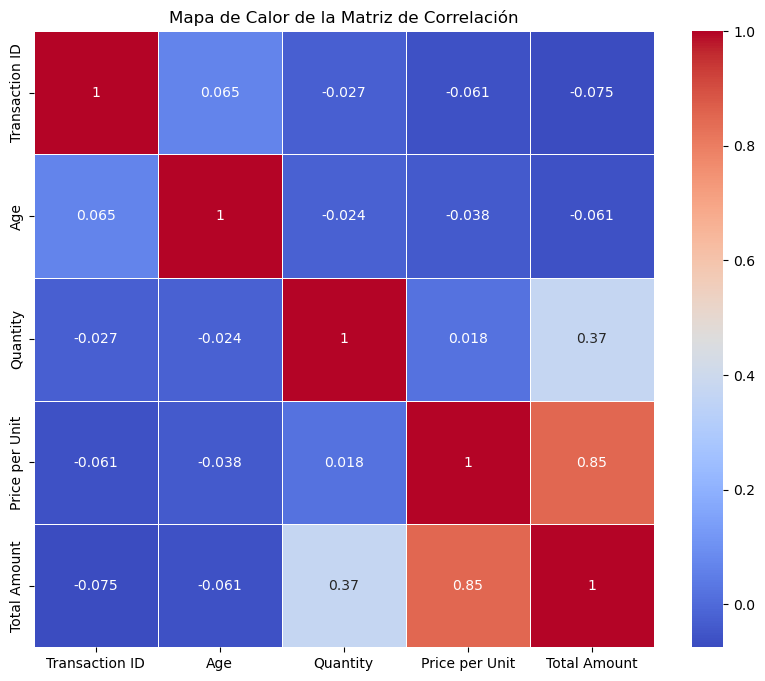

In [6]:
# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Crear un mapa de calor para visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

- Variables correlacionadas:

La correlación más alta se observa entre Price per Unit y Total Amount (0.85), lo cual tiene sentido, ya que el monto total probablemente sea el resultado del precio por unidad multiplicado por la cantidad.
Hay una correlación moderada (0.37) entre Quantity y Total Amount, lo cual indica que las cantidades compradas también tienen impacto en el monto total.
- Variables con baja o nula correlación:

Transaction ID no tiene correlaciones significativas con ninguna otra variable, lo cual es esperado ya que probablemente sea solo un identificador único.
Age muestra una correlación cercana a cero con todas las demás variables, indicando que la edad de los compradores no parece influir directamente en las cantidades, precios o montos.
- Interpretación general:

Las relaciones más relevantes para este conjunto de datos son las relacionadas con Price per Unit y Total Amount, lo que sugiere que el modelo de predicción debería priorizar estas variables.

### Visualización de Datos:

- Crear subplots para comparar diferentes variables clave.
- Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información.

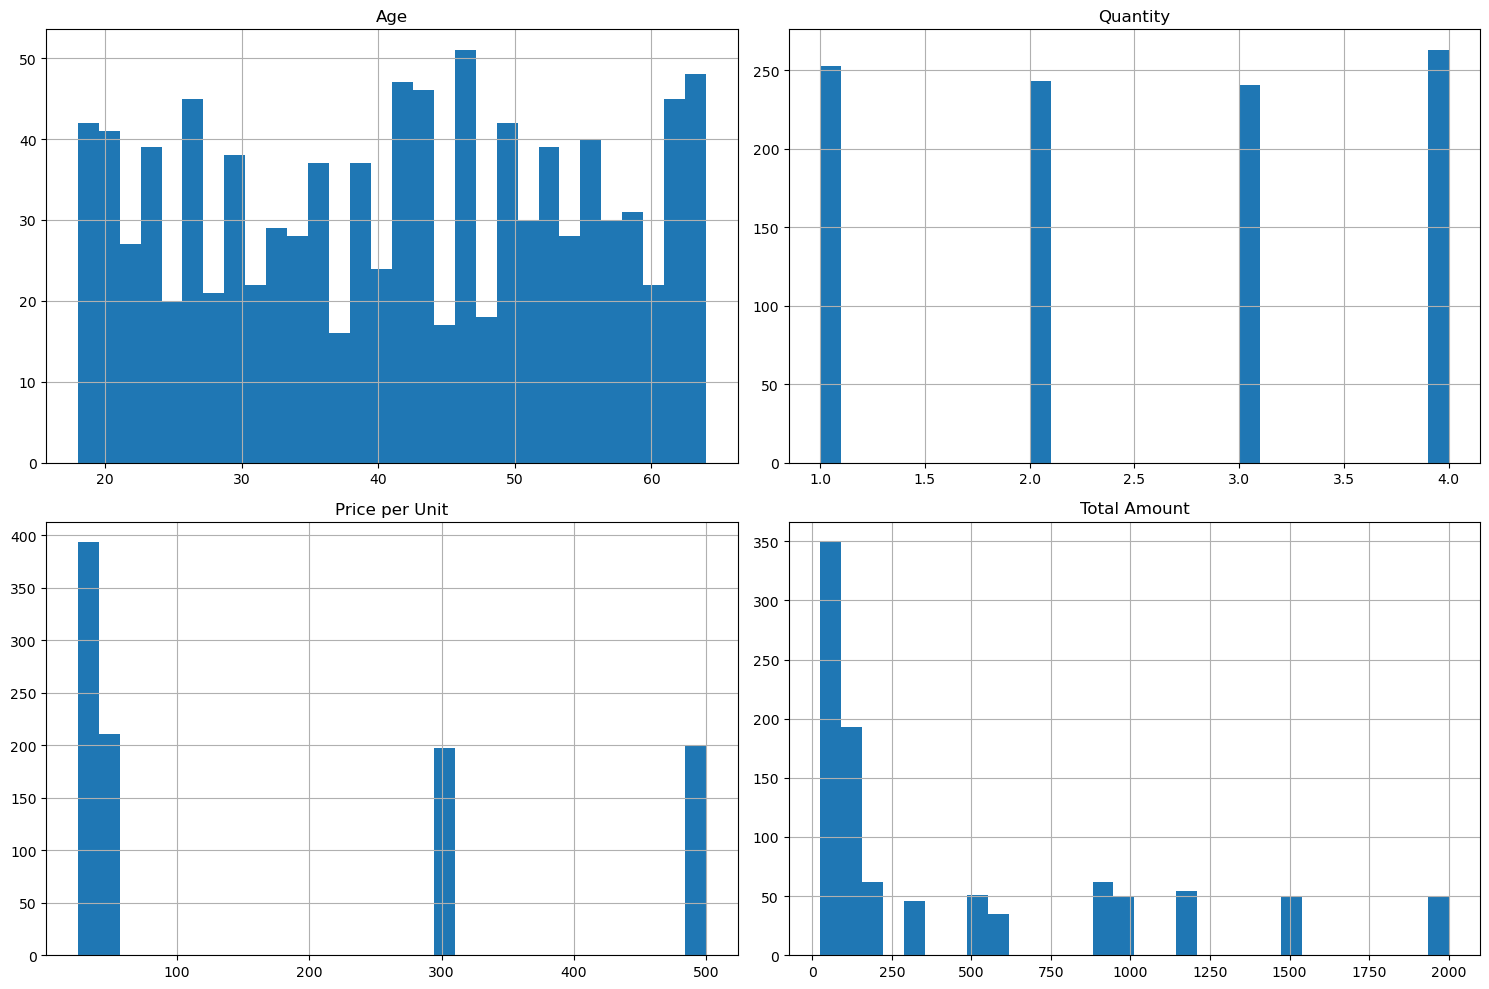

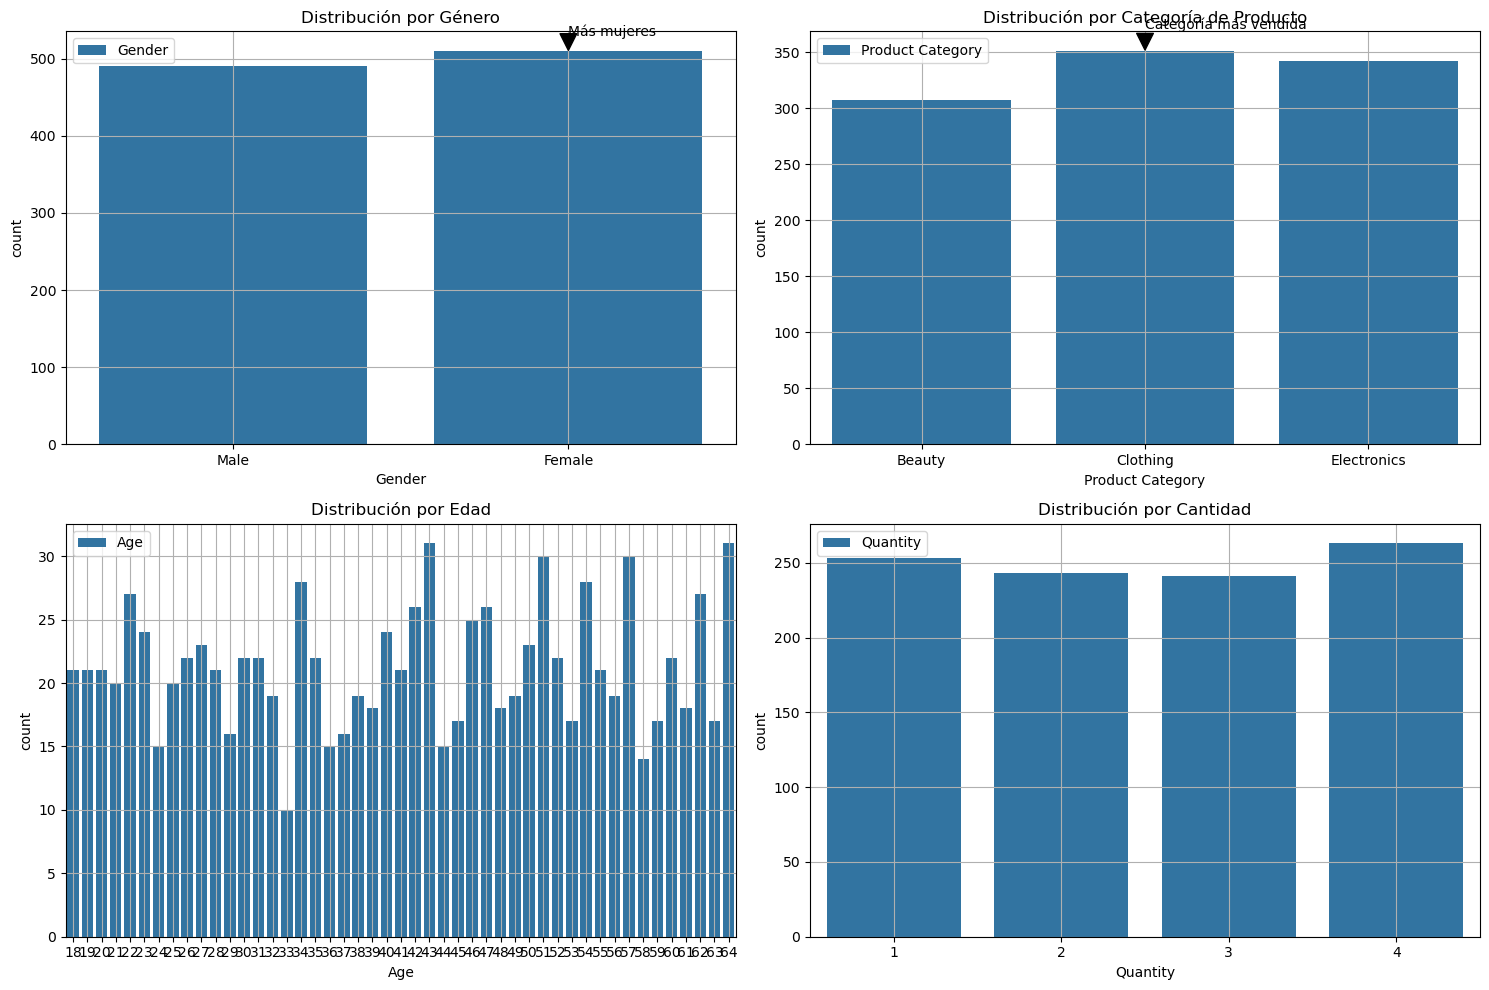

In [7]:
# Visualización de la distribución de las variables numéricas, excluyendo 'Transaction ID'
df.drop(columns=['Transaction ID']).hist(bins=30, figsize=(15, 10), grid=True)
plt.tight_layout()
plt.show()

# Visualización de la distribución de las variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico de Género
sns.countplot(ax=axes[0, 0], x='Gender', data=df)
axes[0, 0].set_title('Distribución por Género')
axes[0, 0].grid(True)
axes[0, 0].legend(['Gender'])
axes[0, 0].annotate('Más mujeres', xy=(1, df['Gender'].value_counts()['Female']), xytext=(1, df['Gender'].value_counts()['Female'] + 20),
                   arrowprops=dict(facecolor='black', shrink=0.05))

# Gráfico de Categoría de Producto
sns.countplot(ax=axes[0, 1], x='Product Category', data=df)
axes[0, 1].set_title('Distribución por Categoría de Producto')
axes[0, 1].grid(True)
axes[0, 1].legend(['Product Category'])
axes[0, 1].annotate('Categoría más vendida', xy=(df['Product Category'].value_counts().idxmax(), df['Product Category'].value_counts().max()), 
                   xytext=(df['Product Category'].value_counts().idxmax(), df['Product Category'].value_counts().max() + 20),
                   arrowprops=dict(facecolor='black', shrink=0.05))

# Gráfico de Edad
sns.countplot(ax=axes[1, 0], x='Age', data=df)
axes[1, 0].set_title('Distribución por Edad')
axes[1, 0].grid(True)
axes[1, 0].legend(['Age'])

# Gráfico de Cantidad
sns.countplot(ax=axes[1, 1], x='Quantity', data=df)
axes[1, 1].set_title('Distribución por Cantidad')
axes[1, 1].grid(True)
axes[1, 1].legend(['Quantity'])
axes[1, 1].annotate('Cantidad más común', xy=(df['Quantity'].mode()[0], df['Quantity'].value_counts().max()), 
                   xytext=(df['Quantity'].mode()[0], df['Quantity'].value_counts().max() + 10),
                   arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()


- Distribución por Edad:

Muestra la cantidad de datos distribuidos en intervalos de edad. Parece una distribución uniforme con algunas fluctuaciones.
- Cantidad:

Un histograma con valores discretos, probablemente la cantidad de productos vendidos. Los valores más frecuentes están bien marcados en el eje X.
- Precio por Unidad:

Indica una distribución con valores concentrados en ciertos puntos específicos, posiblemente relacionados con los precios estandarizados de productos.
- Monto Total:

Evidencia una concentración en montos menores, con pocos valores en rangos altos, lo que podría implicar una tendencia de ventas de bajo costo o alta frecuencia.

- Género:

Gráfico de barras mostrando una distribución casi equitativa entre hombres y mujeres en los datos de ventas.
- Categoría de Producto:

Tres categorías principales (belleza, ropa y electrónica) con cantidades similares, indicando una distribución balanceada de las ventas entre estos grupos.
- Edad:

Histograma de frecuencia más detallado que muestra un conteo preciso por edad, destacando una distribución uniforme.
- Cantidad:

Distribución de valores discretos en las cantidades compradas, reflejando datos similares al gráfico correspondiente en el primer conjunto.